In [27]:
import sys
sys.path.append('../src')

import torch
#noinspection PyUnresolvedReferences
from model import UNet
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [28]:
model = UNet(in_channels=1, out_channels=3)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")

Всего параметров: 31,042,499
Обучаемых параметров: 31,042,499


In [29]:
# Тест на случайном батче
x = torch.randn(4, 1, 32, 32)
y = model(x)

print(f"Вход: {x.shape}")
print(f"Выход: {y.shape}")
print(f"Диапазон значений на выходе: [{y.min().item():.2f}, {y.max().item():.2f}]")

Вход: torch.Size([4, 1, 32, 32])
Выход: torch.Size([4, 3, 32, 32])
Диапазон значений на выходе: [-1.64, 1.14]


In [30]:
# Проверка на реальных данных
gray_path = "../data/processed/cifar10/gray/00000.png"
gray_img = Image.open(gray_path)

transform = transforms.Compose([
    transforms.ToTensor(),
])

x_real = transform(gray_img).unsqueeze(0)  # [1, 1, 32, 32]

with torch.no_grad():
    y_real = model(x_real)  # [1, 3, 32, 32]

print(f"Реальная ч/б картинка загружена")
print(f"Предсказанный выход: {y_real.shape}")

Реальная ч/б картинка загружена
Предсказанный выход: torch.Size([1, 3, 32, 32])


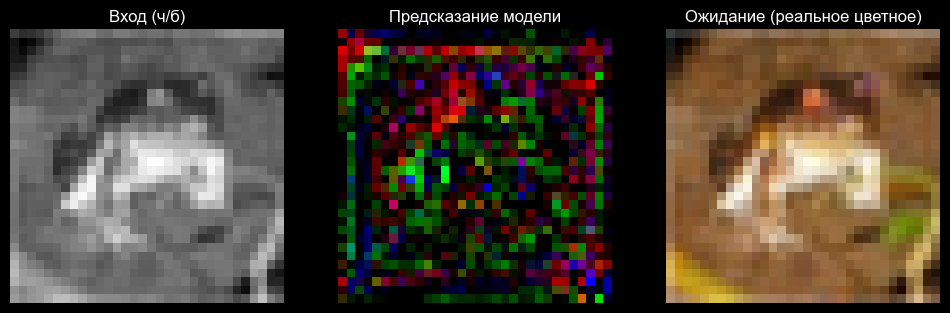

In [31]:
pred_img = y_real.squeeze(0).cpu().detach().numpy()  # [3, 32, 32]
pred_img = np.transpose(pred_img, (1, 2, 0))  # [32, 32, 3]

# Нормализуем обратно в диапазон [0, 1] (если вышло за пределы)
pred_img = np.clip(pred_img, 0, 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(gray_img, cmap='gray')
plt.title("Вход (ч/б)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(pred_img)
plt.title("Предсказание модели")
plt.axis('off')

color_path = "../data/processed/cifar10/color/00000.png"
true_color = Image.open(color_path)

plt.subplot(1, 3, 3)
plt.imshow(true_color)
plt.title("Ожидание (реальное цветное)")
plt.axis('off')

plt.show()

## Результаты проверки модели

✅ Модель UNet успешно инициализирована (1 канал → 3 канала)

✅ Модель корректно обрабатывает входные данные [1, 32, 32] → [3, 32, 32]

✅ Пайплайн предсказания и визуализации работает

⚠️ **Важно:** Пока что модель использует случайные веса (не обучена), поэтому предсказания не соответствуют ожидаемым цветам.